In [1]:
# loading modules

# %load_ext watermark # this is so that in the end we can check which module versions we used
%load_ext autoreload

import warnings 
warnings.filterwarnings("ignore")

import datetime
import glob
import os
import warnings
import dask
import distributed
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import xgcm
from matplotlib import ticker, cm
from cartopy import crs as ccrs, feature as cfeature
import cartopy
from pyproj import CRS, Transformer
import xesmf as xe
from skimage import measure

In [18]:
cism_grid_path = "/glade/u/home/ifairuz/processed_paleo_data/CISM3_initialization_AIS_08000.LatLon.nc"
cism_init_path = "/glade/u/home/ifairuz/processed_paleo_data/CISM3_initialization_AIS_08000.b_h_s_interp_median.m1for0bed.2025-03-03.nc"

lgm_ocn_temp_path = "/glade/u/home/ifairuz/processed_paleo_data/LGM/icesm_lgm21ka_atm_TREFHT_monthly_avg_antarctica.nc"
lig_ocn_temp_path = "/glade/u/home/ifairuz/processed_paleo_data/LIG/icesm_lig127ka_atm_TREFHT_monthly_avg_antarctica.nc"


In [19]:
cism_grid_ds = xr.open_dataset(cism_grid_path)
cism_init_ds = xr.open_dataset(cism_init_path)
lgm_ocn_temp_ds = xr.open_dataset(lgm_ocn_temp_path, chunks={"time": 12})
lig_ocn_temp_ds = xr.open_dataset(lig_ocn_temp_path, chunks={"time": 12})

In [23]:
grid_thick = xr.Dataset(
    {
        "lat": (("y1", "x1"), cism_grid_ds["Lat1"].data),
        "lon": (("y1", "x1"), cism_grid_ds["Lon1"].data)
    }
)

lgm_atm_regridder = xe.Regridder(lgm_ocn_temp_ds, grid_thick, method="bilinear", periodic=True)
lig_atm_regridder = xe.Regridder(lig_ocn_temp_ds, grid_thick, method="bilinear", periodic=True)

lgm_atm_regridder.to_netcdf("lgm21ka_to_cism8km_atm_regridder.nc")
lig_atm_regridder.to_netcdf("lig127ka_to_cism8km_atm_regridder.nc")

dropped_lgm_atm = lgm_ocn_temp_ds[["TREFHT"]]
dropped_lig_atm = lig_ocn_temp_ds[["TREFHT"]]

regridded_lgm_atm = lgm_atm_regridder(dropped_lgm_atm)
regridded_lig_atm = lig_atm_regridder(dropped_lig_atm)

regridded_lgm_atm.to_netcdf("lgm21ka_atm_TREFHT_on_cism8km.nc")
regridded_lig_atm.to_netcdf("lig127ka_atm_TREFHT_on_cism8km.nc")

In [24]:
# Check spatial coverage — should be no NaNs since atm covers full domain
for name, ds in [("LGM", regridded_lgm_atm), ("LIG", regridded_lig_atm)]:
    n_nan = ds.TREFHT.isnull().sum().values
    print(f"{name} NaN count: {n_nan}")

# Check temperature ranges (in °C)
for name, ds in [("LGM", regridded_lgm_atm), ("LIG", regridded_lig_atm)]:
    t = ds.TREFHT - 273.15
    print(f"{name} TREFHT: min={float(t.min()):.1f}°C, max={float(t.max()):.1f}°C, mean={float(t.mean()):.1f}°C")

# LIG should be warmer than LGM — sanity check
diff = (regridded_lig_atm.TREFHT - regridded_lgm_atm.TREFHT).mean()
print(f"LIG - LGM mean difference: {float(diff):.2f} K")

LGM NaN count: 0
LIG NaN count: 0
LGM TREFHT: min=-84.1°C, max=4.1°C, mean=-30.6°C
LIG TREFHT: min=-68.8°C, max=9.9°C, mean=-17.7°C
LIG - LGM mean difference: 12.92 K


In [27]:
lon2d = cism_grid_ds["Lon1"].values
lat2d = cism_grid_ds["Lat1"].values

regridded_lgm_atm = regridded_lgm_atm.assign_coords(
    lat=(("y1", "x1"), lat2d),
    lon=(("y1", "x1"), lon2d)
)
regridded_lig_atm = regridded_lig_atm.assign_coords(
    lat=(("y1", "x1"), lat2d),
    lon=(("y1", "x1"), lon2d)
)

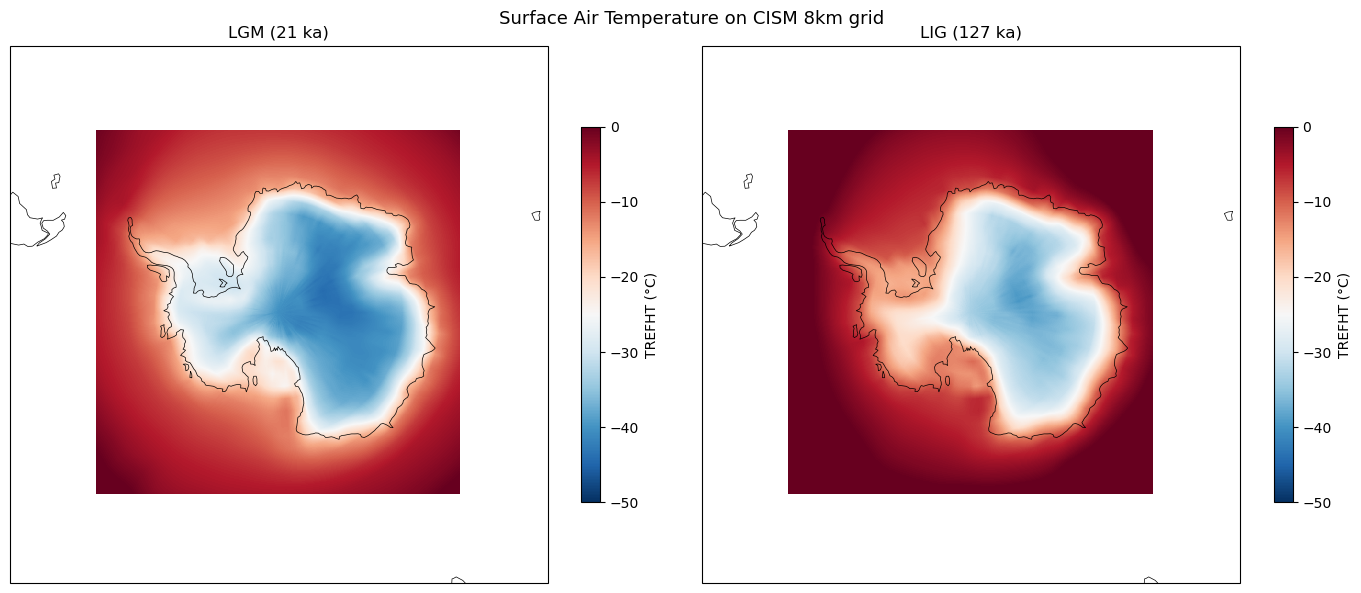

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6),
                         subplot_kw={"projection": ccrs.SouthPolarStereo()})

for ax, ds, title in zip(axes,
                          [regridded_lgm_atm, regridded_lig_atm],
                          ["LGM (21 ka)", "LIG (127 ka)"]):
    ax.set_extent([-180, 180, -90, -50], ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    
    field = ds.TREFHT.isel(time=0) - 273.15

    p = ax.pcolormesh(
        ds.lon.values,
        ds.lat.values,
        field.values,
        transform=ccrs.PlateCarree(),
        cmap="RdBu_r",
        vmin=-50, vmax=0
    )
    plt.colorbar(p, ax=ax, label="TREFHT (°C)", shrink=0.7)
    ax.set_title(title)

plt.suptitle("Surface Air Temperature on CISM 8km grid", fontsize=13)
plt.tight_layout()
#plt.savefig("LGM_LIG_atm_TREFHT_cism8km.png", dpi=150)
plt.show()